# INTRODUÇÃO E CONTEXTO
Uma usina termoelétrica de ciclo combinado (UTCC) é uma instalação de alta eficiência que combina turbinas  gás e a vapor para gerar eletricidade. Ela reaproveita o calor dos gases de exaustão da turbina a gás(ciclo Brayton) para produzir vapor em uma caldeira, acionando uma segunda turbina (ciclo Rankine), aumentando significativamente o rendimento. A principal vantagem e a eficiência energética, que pode chegar a 60%, reduzindo as emissões de gases de efeito estufa.

Embora apresente alta eficiência, o principal desafio técnico no uso de uma usina UTCC reside na integração,  sincronização e operação conjunta de dois ciclos termodinâmicos distintos (ciclo Brayton e ciclo Rankine) para funcionar de forma eficiente. Assim sendo, a potência elétrica de saída (PE) e altamente sensível às condições ambientais.

Neste projeto, voce deve construir um modelo matemático de regressão linear múltipla para prever a produção de energia baseando-se em sensores ambientais, permitindo a otimização do despacho energético.

# CONJUNTO DE DADOS
Para realizar o treinamento do nosso modelo, utilizamos o dataset UCI CCPP (disponível em [DataSet](https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant)). O dataset contém 9.568 amostras coletadas ao longo de 6 anos. Cada amostra possui as seguintes variáveis:

- AT (Ambient Temperature): Temperatura em °C. Afeta a densidade do ar e a eficiência da combustão.

- V (Exhaust Vacuum): Vacuo de escape em cm Hg. Relacionado a pressão na turbina a vapor.

- AP (Ambient Pressure): Pressão atmosférica em mbar.

- RH (Relative Humidity): Umidade relativa em percentagem.

- PE (Net Hourly Electrical Energy Output): A variável alvo em MW (MegaWatts).

In [9]:
from ucimlrepo import fetch_ucirepo # Baixar o dataset
import matplotlib.pyplot as plt # Plotar os gráficos
import numpy as np # Manipulação de arrays
import pandas as pd # Utilizar o data frames
from sklearn.model_selection import train_test_split # Separar o conjunto de treinamento e teste
from sklearn.linear_model import LinearRegression # Modelo de regressão linear
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error # Métricas para medição do desempenho do modelo

In [10]:
combined_cycle_power_plant = fetch_ucirepo(id=294) # Busca o dataset pelo identificador

X = combined_cycle_power_plant.data.features # Pega no formato dataframe as variáveis independentes
y = combined_cycle_power_plant.data.targets # Pega no formato dataframe a variável alvo

ConnectionError: Error connecting to server

In [ ]:
X # Mostrando as variáveis independentes

,AT,V,AP,RH
0,14.96,41.76,1024.07,73.17
1,25.18,62.96,1020.04,59.08
2,5.11,39.40,1012.16,92.14
3,20.86,57.32,1010.24,76.64
4,10.82,37.50,1009.23,96.62
...,...,...,...,...
9563,16.65,49.69,1014.01,91.00
9564,13.19,39.18,1023.67,66.78
9565,31.32,74.33,1012.92,36.48
9566,24.48,69.45,1013.86,62.39


In [ ]:
y # Mostrando a variável alvo.

,PE
0,463.26
1,444.37
2,488.56
3,446.48
4,473.90
...,...
9563,460.03
9564,469.62
9565,429.57
9566,435.74


# Correlação

(Questão) Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) e a variável dependente (PE). Quais variáveis parecem ter maior influência na produção de energia?

(Resposta) Ao calcular a correlação entre as variáveis independentes (AT, V, AP, RH) e a variável alvo (PE), observamos os seguintes resultados:

- AT (-0.94): Possui a maior correlação, sendo inversamente proporcional (quanto mais alta a temperatura, menor a geração de energia).

- V (-0.86): Possui a segunda correlação mais forte, também inversamente proporcional.

- AP (0.51): Apresenta uma correlação moderada e diretamente proporcional.

- RH (0.38): Apresenta uma correlação baixa e diretamente proporcional.

Assim, a Temperatura Ambiente (AT) e o Vácuo de Exaustão (V) são as variáveis que exercem a maior influência na produção de energia do modelo.

In [ ]:
pd.concat([X, y], axis=1).corr()["PE"].drop("PE") # Concatena o dataset das variáveis dependentes com a variável alvo e calcula a correlação entre as variáveis independentes e a variável alvo.

AT   -0.948128
V    -0.869780
AP    0.518429
RH    0.389794
Name: PE, dtype: float64

(Questão) Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) entre si. Existe alguma relação forte entre elas? Se sim, isso pode indicar multicolinearidade.

(Resposta) Existe uma forte correlação positiva (0.84) entre a Temperatura Ambiente (AT) e o Vácuo de Exaustão (V). Isso mostra que essas variáveis estão fortemente correlacionadas entre si, o que é um indício de multicolinearidade, significando que ambas trazem informações parcialmente redundantes para o modelo matemático.

In [ ]:
X.corr() # Calcula a correlação entre as variáveis independentes.

,AT,V,AP,RH
AT,1.000000,0.844107,-0.507549,-0.542535
V,0.844107,1.000000,-0.413502,-0.312187
AP,-0.507549,-0.413502,1.000000,0.099574
RH,-0.542535,-0.312187,0.099574,1.000000


# Treino

(Questão) Construa um modelo de regressão linear múltipla utilizando as variáveis independentes (AT, V, AP, RH) para prever a variável dependente (PE). Divida os dados em treino (80%) e teste (20%).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # Separa o conjunto de treinamento (80%) e teste (20%)

print(f"Tamanho do dataset =                    {X.shape[0]} amostras.")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras.")
print(f"Quantidade de amostras de teste =       {X_test.shape[0]} amostras.")

Tamanho do dataset =                    9568 amostras.
Quantidade de amostras de treinamento = 7654 amostras.
Quantidade de amostras de teste =       1914 amostras.


In [ ]:
model = LinearRegression() # Cria um  modelo de regressão linear
model.fit(X_train, y_train) # Treina o modelo com os dados do treinamento

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Avaliação

(Questão) Avalie o desempenho do modelo utilizando métricas como $R^2$, RMSE e MAE. O modelo e adequado para prever a produção de energia? Justifique sua resposta.

- Coeficiente de Determinação ($R^2$): Varia entre 0 e 1 e mede o percentual da variação da variável alvo que o modelo consegue explicar através das variáveis independentes fornecidas.

- Erro Médio Absoluto (MAE): Representa a média da diferença absoluta (ignorando sinais negativos) entre a previsão do modelo e o valor real.

- Raiz do Erro Quadrático Médio (RMSE): É uma métrica semelhante ao MAE, mas, por elevar as diferenças ao quadrado antes de tirar a média, o RMSE penaliza mais severamente erros de previsão muito grandes (outliers).

(Resposta)

- $R^2$: O resultado de 0.93 significa que o modelo consegue explicar 93% da variância na geração de energia.

- MAE: O resultado mostra que a previsão do modelo desvia da geração real em uma média de apenas 3.60 MW. Como a geração total oscila entre 420 e 490 MW, trata-se de um erro muito pequeno (inferior a 1%).

- RMSE: O resultado de 4.50 MW, por ser baixo e estar próximo ao MAE, indica que o modelo possui uma margem de erro consistente e não comete erros discrepantes (não é excessivamente sensível a outliers).

Conclusão: Sim, o modelo é altamente adequado para a previsão em produção. O excelente coeficiente $R^2$, combinado com erros muito pequenos representados pelo MAE e RMSE, atesta que a regressão linear múltipla é capaz de otimizar o despacho energético.


In [ ]:
y_pred = model.predict(X_test) # Faz a predição do conjunto de teste

rmse = root_mean_squared_error(y_test, y_pred) # Calcula a raiz do erro absoluto
r2 = r2_score(y_test, y_pred) # Calcula o coeficiente de determinação
mae = mean_absolute_error(y_test, y_pred) # Calcula o erro médio absoluto

print(f"Coeficiente de determinação (R²):     {r2:.2f}")
print(f"Erro médio absoluto (MAE):            {mae:.2f}")
print(f"Raiz do erro quadrático médio (RMSE): {rmse:.2f}")

Raiz do erro quadrático médio (RMSE): 4.50
Coeficiente de determinação (R²): 0.93
Erro médio absoluto (MAE): 3.60


# Gráfico

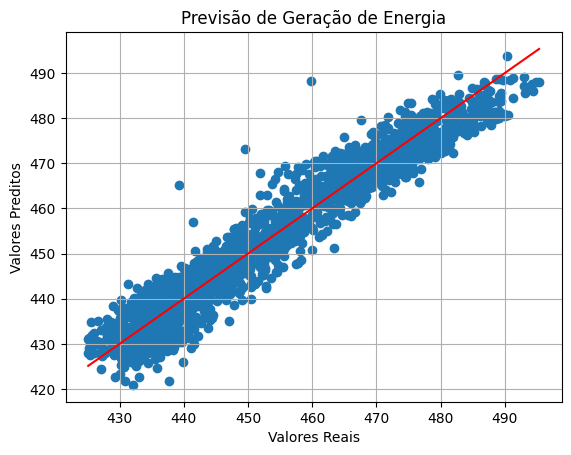

In [ ]:
y_test_min = np.min(y_test) # Pega o menor valor do conjunto de teste
y_test_max = np.max(y_test) # Pega o maior valor do conjunto de teste

y_ideal = np.linspace(y_test_min, y_test_max, 1000) # Linha base para criação da linha de predição

plt.plot(y_ideal, y_ideal, 'r') # Desenha a linha ideal onde o valor previsto é igual ao real
plt.scatter(y_test, y_pred) # Adiciona as amostras no gráficos (pontinhos azuis)
plt.xlabel("Valores Reais") # rótulo do eixo x
plt.ylabel("Valores Preditos") # rótulo do eixo y
plt.title("Previsão de Geração de Energia") # Nome do gráfico
plt.grid(True) # Adiciona uma grade ao gráfico
plt.show() # mostrar o gráfico